In [ ]:
import pandas as pd
import numpy as np


Data = pd.read_csv("/content/NetPhish_V2.csv")
display(Data.head())
Data.shape

<ipython-input-1-fff8d3e3bca4>:5: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  Data = pd.read_csv("/content/NetPhish_V2.csv")


,url_length,num_dots,has_hyphen,has_at_symbol,path_length,query_length,num_params,tld_length,uses_https,url_depth,...,num_underscores,domain_age_days,site_rank,netblock_owner,asn,reverse_dns_present,organisation,dnsssec,is_netblock_trusted,class
0,46.0,1.0,1.0,0.0,27.0,0.0,0.0,2.0,1.0,3.0,...,0.0,792.0,NaN,Megagroup.ru LLC,60357.0,0.0,0.0,1.0,0,0.0
1,45.0,1.0,1.0,0.0,26.0,0.0,0.0,2.0,1.0,3.0,...,0.0,792.0,NaN,Megagroup.ru LLC,60357.0,0.0,0.0,1.0,0,0.0
2,105.0,1.0,0.0,0.0,82.0,0.0,0.0,2.0,1.0,4.0,...,0.0,2373.0,NaN,Hostinger International Limited,47583.0,0.0,1.0,1.0,1,0.0
3,91.0,2.0,1.0,0.0,19.0,0.0,0.0,2.0,1.0,2.0,...,0.0,1612.0,NaN,GANDI DEDICATED HOSTING SERVERS,203476.0,1.0,0.0,1.0,0,0.0
4,82.0,1.0,0.0,0.0,57.0,0.0,0.0,3.0,1.0,4.0,...,0.0,3592.0,NaN,"Shopify, Inc.",13335.0,1.0,0.0,1.0,1,0.0


(77492, 34)

### **EDA of Dataset**

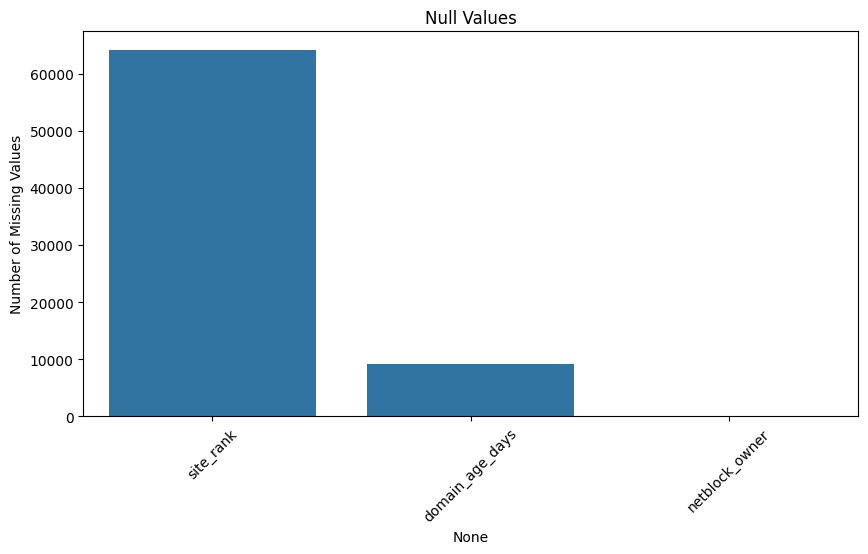

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

null = Data.isnull().sum()
null_value = null[null > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=null_value.index, y=null_value.values)
plt.title('Null Values')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

In [ ]:
from scipy import stats

num_cols = Data.select_dtypes(include=np.number).columns.tolist()
outlier_counts = {}

for col in num_cols:
    if Data[col].nunique() > 10:
        z = np.abs(stats.zscore(Data[col].dropna()))
        outlier_counts[col] = (z > 3).sum()

outlier = pd.DataFrame(list(outlier_counts.items()), columns=['Feature name', 'Outlier Count'])
outlier = outlier.sort_values('Outlier Count', ascending=False)
print(outlier)


             Feature name  Outlier Count
9       num_special_chars           1440
12       num_unique_chars           1318
11  digit_to_length_ratio           1204
15        domain_age_days           1177
2             path_length           1155
4              num_params           1054
7           domain_length            993
8         hostname_length            978
6               url_depth            798
0              url_length            795
3            query_length            769
14        num_underscores            505
13  file_extension_length            487
1                num_dots            448
5              tld_length            337
10        fragment_length            152
16              site_rank              0


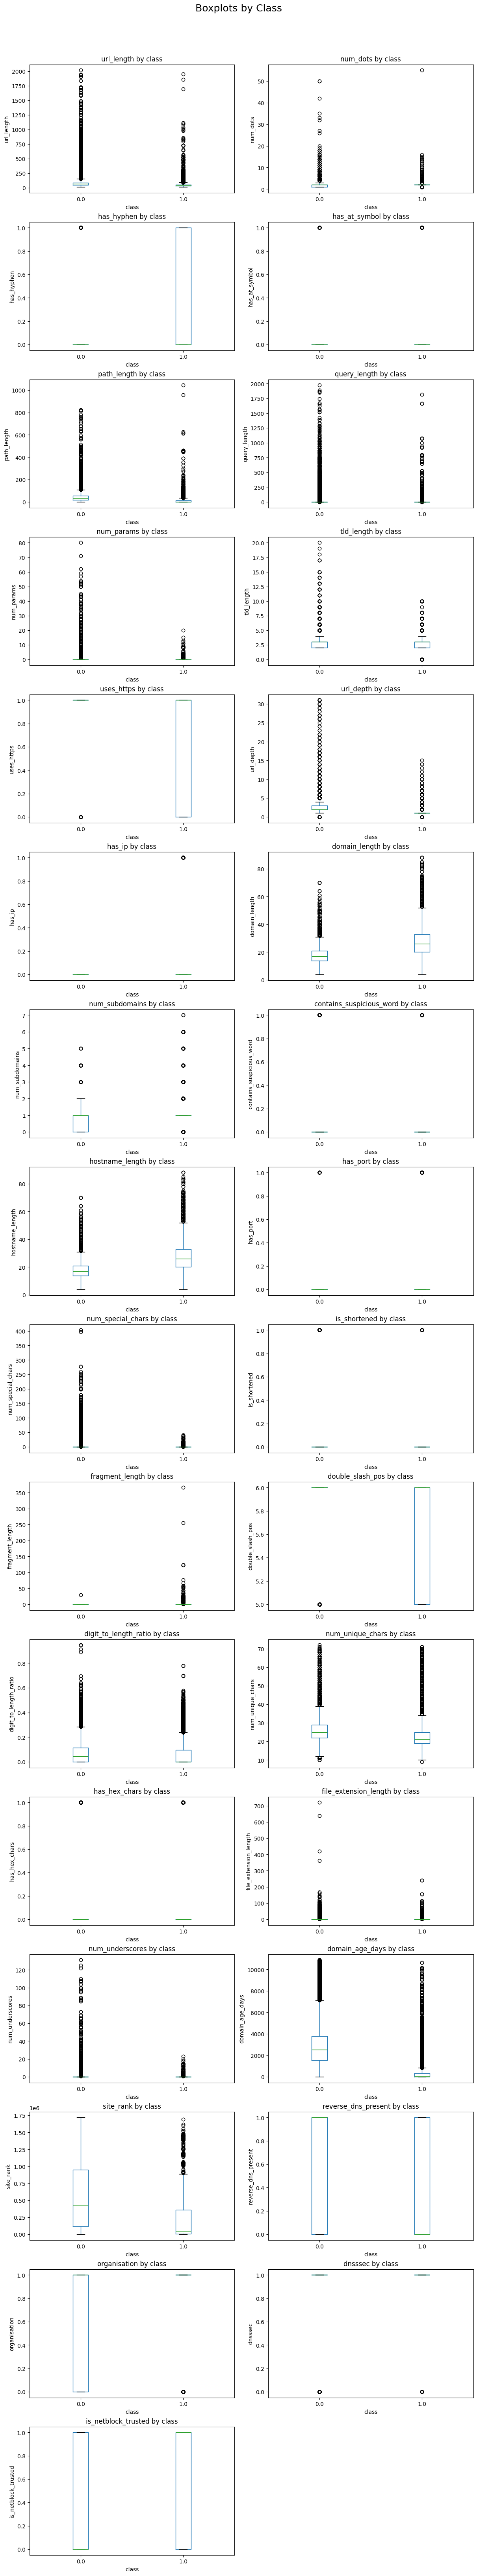

In [ ]:
import math

# Filter numeric features
numeric = Data.select_dtypes(include=np.number).columns.tolist()
if 'class' in numeric:
    numeric.remove('class')

n_cols = 2
n_plots = len(numeric)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows), constrained_layout=True)
for i, col in enumerate(numeric):
    ax = axes[i // n_cols, i % n_cols] if n_rows > 1 else axes[i % n_cols]
    Data.boxplot(column=col, by='class', grid=False, ax=ax)
    ax.set_title(f"{col} by class")
    ax.set_xlabel("class")
    ax.set_ylabel(col)

for j in range(n_plots, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

fig.suptitle('Boxplots by Class', fontsize=18, y=1.02)
plt.show()


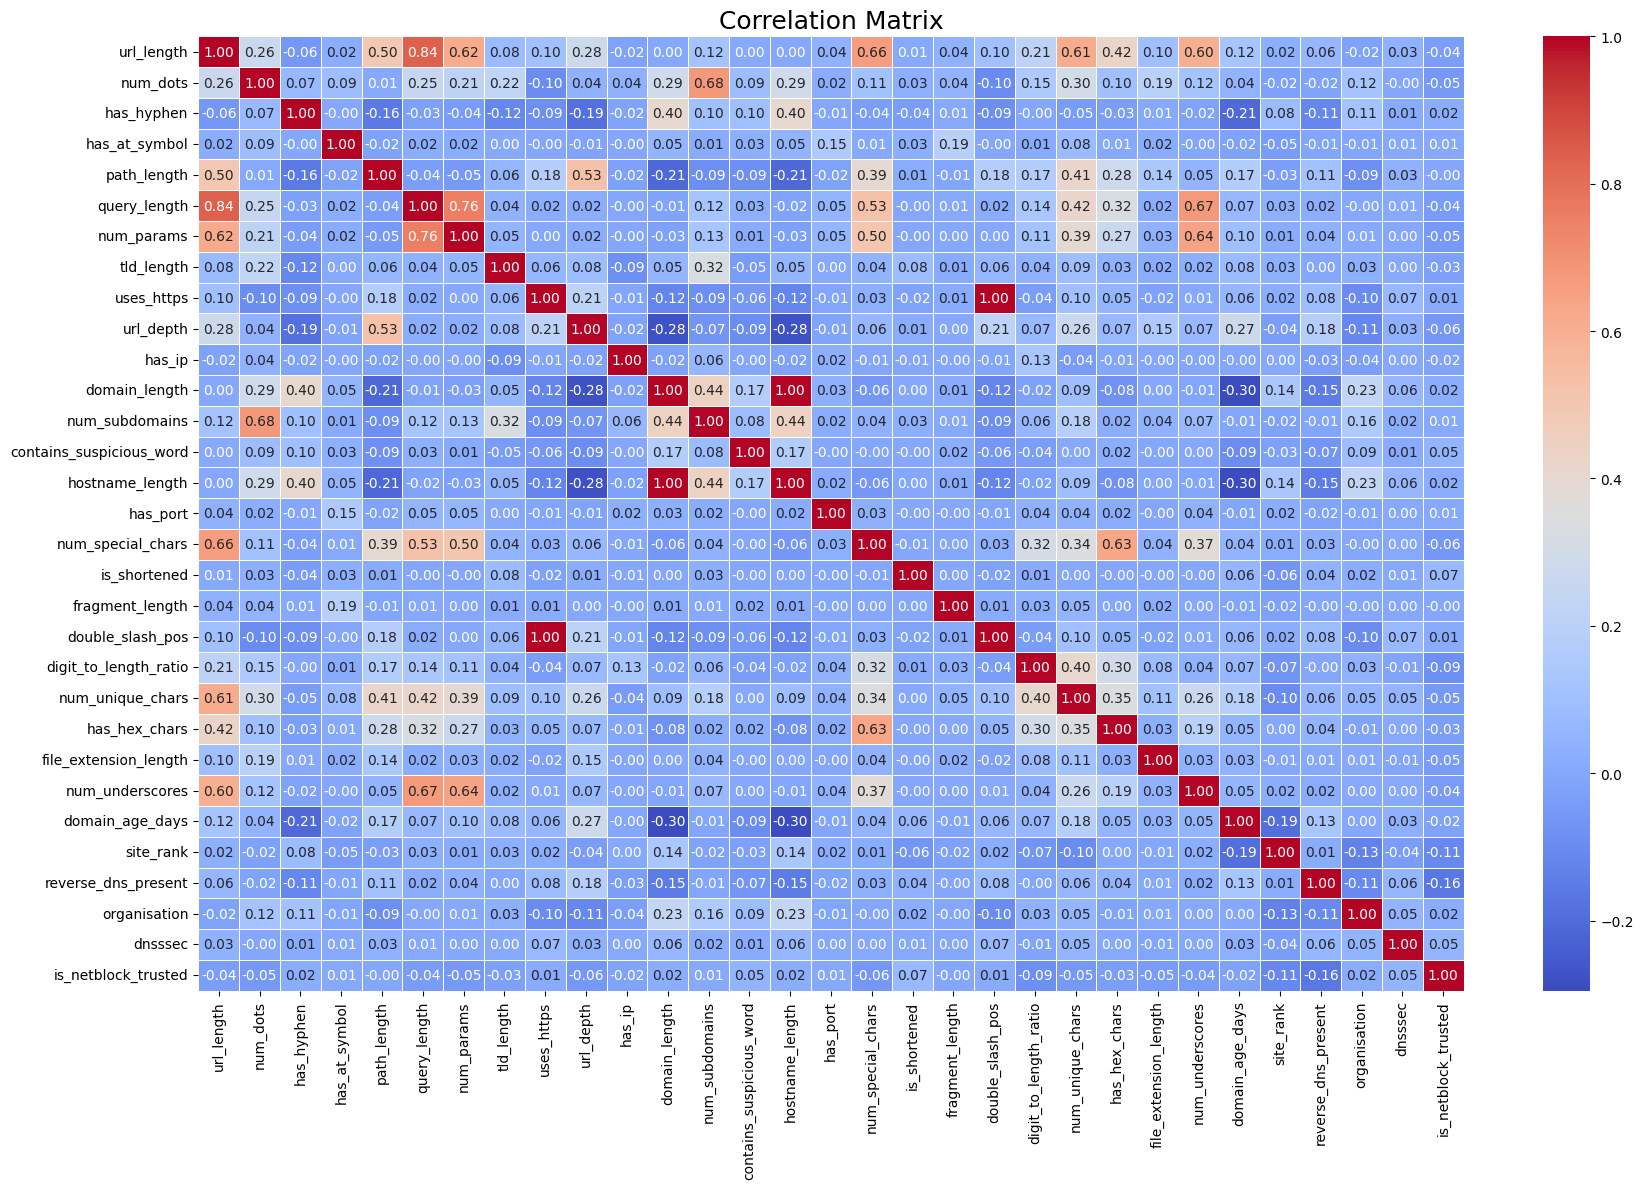

In [ ]:
corr = Data[numeric].corr()

plt.figure(figsize=(18, 12))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5, cmap='coolwarm')
plt.title("Correlation Matrix", fontsize=18)
plt.tight_layout()
plt.show()


In [ ]:
corr_pairs = corr.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs.index = [tuple(sorted(pair)) for pair in corr_pairs.index]
corr_pairs = corr_pairs[~corr_pairs.index.duplicated(keep='first')]
corr_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

print("Positive correlation scores:\n")
for (feature1, feature2), score in corr_pairs.items():
    if score > 0:
        print(f"{feature1:25} {feature2:25} {score:.4f}")


Positive correlation scores:

domain_length             hostname_length           0.9996
double_slash_pos          uses_https                0.9980
query_length              url_length                0.8377
num_params                query_length              0.7554
num_dots                  num_subdomains            0.6810
num_underscores           query_length              0.6741
num_special_chars         url_length                0.6642
num_params                num_underscores           0.6444
has_hex_chars             num_special_chars         0.6321
num_params                url_length                0.6205
num_unique_chars          url_length                0.6110
num_underscores           url_length                0.6033
num_special_chars         query_length              0.5265
path_length               url_depth                 0.5261
num_params                num_special_chars         0.5047
path_length               url_length                0.4962
domain_length             

Class Feature:
class
0.0    52231
1.0    25261
Name: count, dtype: int64
class
0.0    67.401796
1.0    32.598204
Name: proportion, dtype: float64


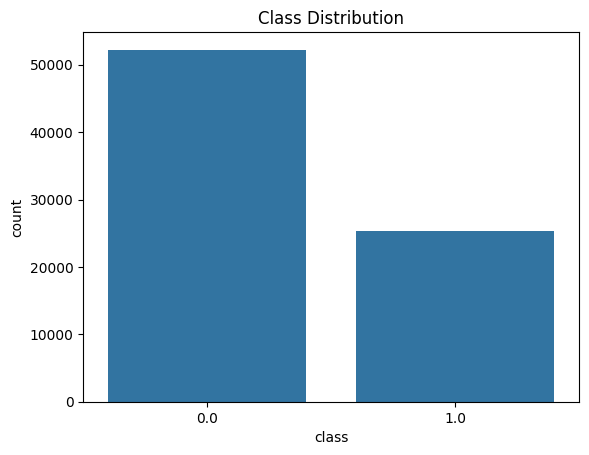

In [ ]:
print("Class Feature:")
print(Data['class'].value_counts())
print(Data['class'].value_counts(normalize=True) * 100)

sns.countplot(x='class', data=Data)
plt.title("Class Distribution")
plt.show()


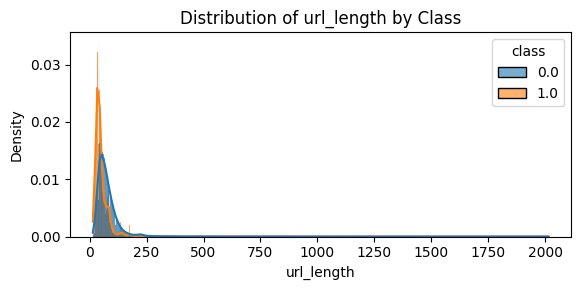

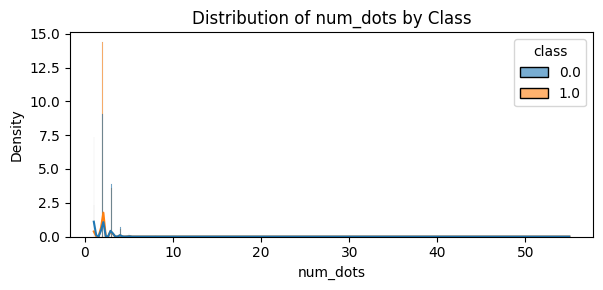

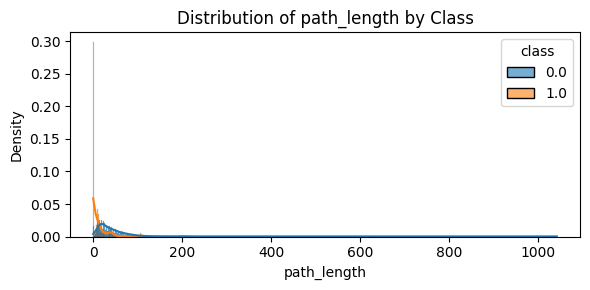

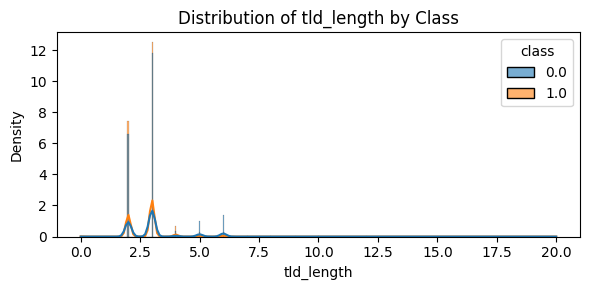

In [ ]:
features_to_plot = ['url_length', 'num_dots', 'path_length', 'tld_length']  # Modify based on your dataset

for col in features_to_plot:
    if col in Data.columns:
        plt.figure(figsize=(6,3))
        sns.histplot(data=Data, x=col,
                     hue='class', kde=True, stat='density',
                     common_norm=False, alpha=0.6)
        plt.title(f'Distribution of {col} by Class')
        plt.xlabel(col)
        plt.ylabel('Density')
        plt.tight_layout()
        plt.show()


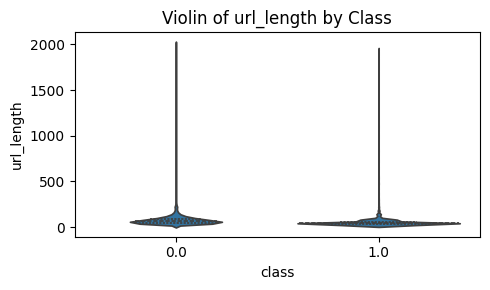

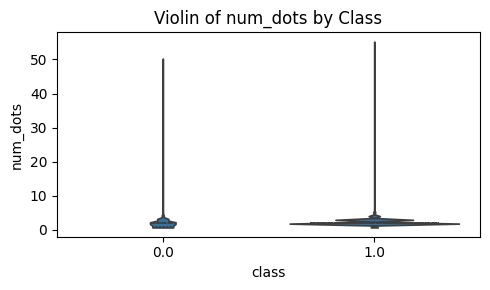

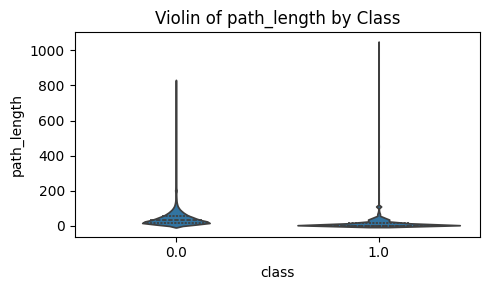

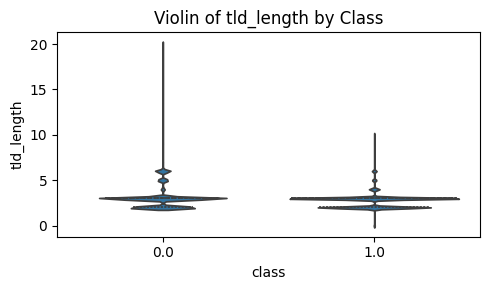

In [ ]:
for col in features_to_plot:
    if col in Data.columns:
        plt.figure(figsize=(5,3))
        sns.violinplot(data=Data, x='class', y=col, inner='quartile')
        plt.title(f'Violin of {col} by Class')
        plt.xlabel('class')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


Top features by |corr| with class:
 domain_length          0.486622
hostname_length        0.486442
url_depth              0.468505
domain_age_days        0.452118
path_length            0.359862
has_hyphen             0.319208
uses_https             0.263881
double_slash_pos       0.263434
organisation           0.256564
reverse_dns_present    0.231615
dtype: float64


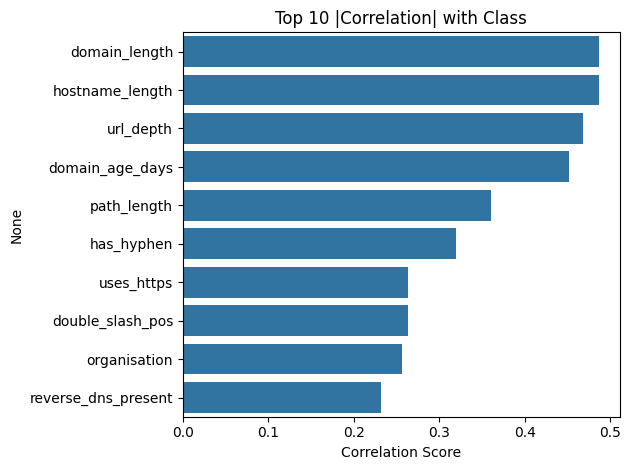

In [ ]:
corr_series = Data[numeric].corrwith(Data['class']).abs().sort_values(ascending=False)
print("Top features by |corr| with class:\n", corr_series.head(10))

sns.barplot(x=corr_series.head(10).values, y=corr_series.head(10).index)
plt.title("Top 10 |Correlation| with Class")
plt.xlabel("Correlation Score")
plt.tight_layout()
plt.show()


## **Preprocessing of Dataset**


In [ ]:
Data.drop_duplicates(inplace=True)
print(f"Data shape after dropping duplicates: {Data.shape}")

Data shape after dropping duplicates: (77434, 34)


In [ ]:
phishing = Data[Data['class'] == 1]
legit = Data[(Data['class'] == 0) & (Data['netblock_owner'].notnull())].sample(n=25203, random_state=42)
balanced = pd.concat([phishing, legit], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
balanced = balanced.drop(['domain_age_days', 'site_rank'], axis=1, errors='ignore')
balanced['asn'] = balanced['asn'].astype(str).str.replace(r'^AS', '', case=False, regex=True)

print(balanced['class'].value_counts())

class
0.0    25203
1.0    25203
Name: count, dtype: int64


In [ ]:
trusted_netblock_owners = [
    "Google LLC", "Amazon.com, Inc.", "Microsoft Corporation", "Cloudflare, Inc.", "DigitalOcean, LLC",
    "Alibaba Cloud LLC", "Oracle Corporation", "OVH Hosting, Inc.", "Hetzner Online GmbH",
    "GoDaddy.com, LLC", "GitHub, Inc.", "Fastly, Inc.", "Hostinger International Limited",
    "Facebook, Inc.", "Shopify, Inc.", "Namecheap, Inc.", "IONOS Inc.", "Fly.io, Inc."
]
normalized_trusted_owners = [owner.lower().strip() for owner in trusted_netblock_owners]

balanced['netblock_owner'] = balanced['netblock_owner'].fillna('')
balanced['netblock_owner_normalized'] = balanced['netblock_owner'].astype(str).str.lower().str.strip()
balanced['is_netblock_trusted'] = balanced['netblock_owner_normalized'].apply(
    lambda x: 1 if x in normalized_trusted_owners else 0
)

balanced.drop('netblock_owner_normalized', axis=1, inplace=True)
balanced.drop('netblock_owner', axis=1, inplace=True)

cols = list(balanced.columns)
cols.remove('is_netblock_trusted')
cols.insert(len(cols) - 1, 'is_netblock_trusted')
balanced = balanced[cols]

display(balanced.head())
balanced.shape

,url_length,num_dots,has_hyphen,has_at_symbol,path_length,query_length,num_params,tld_length,uses_https,url_depth,...,num_unique_chars,has_hex_chars,file_extension_length,num_underscores,asn,reverse_dns_present,organisation,dnsssec,is_netblock_trusted,class
0,36.0,2.0,0.0,0.0,11.0,0.0,0.0,2.0,1.0,2.0,...,20.0,0.0,0.0,0.0,16509.0,1.0,1.0,1.0,0,0.0
1,60.0,4.0,0.0,0.0,31.0,0.0,0.0,2.0,1.0,3.0,...,30.0,0.0,4.0,1.0,224.0,0.0,1.0,1.0,0,0.0
2,36.0,2.0,1.0,0.0,1.0,0.0,0.0,2.0,1.0,1.0,...,19.0,0.0,0.0,0.0,13335.0,0.0,1.0,1.0,1,1.0
3,50.0,1.0,0.0,0.0,33.0,0.0,0.0,3.0,1.0,3.0,...,22.0,0.0,0.0,0.0,7684.0,0.0,0.0,1.0,0,0.0
4,127.0,2.0,0.0,0.0,102.0,0.0,0.0,3.0,1.0,6.0,...,29.0,0.0,4.0,0.0,13335.0,0.0,1.0,1.0,1,0.0


(50406, 31)

In [ ]:
balanced.to_csv('NetPhish_V3.csv', index=False)